# 다변량 Empirical-Bayes

gene×event-type의 class weight 행렬을 rank 4/8 저랭크 공유 구조로 수축합니다. P1+EB의 토큰 정의는 유지하고, 희귀 암종 간 정보 공유만 검증합니다.

seed 42 screen만 수행합니다. 사전 승격 조건(+0.010, 4/5 fold 양수, 안전성 통과)을 만족한 하나의 구성만 3-seed로 확장합니다.


In [1]:
from pathlib import Path
import subprocess, sys
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
            if (path / "experiments/gs/notebooks/exp_model_003/common/run_p1_eb_axis.py").exists())
COMMON = ROOT / "experiments/gs/notebooks/exp_model_003/common"
RESULT = ROOT / "experiments/gs/notebooks/exp_model_003/result"
RUNNER = COMMON / "run_p1_eb_axis.py"
assert RUNNER.exists(), RUNNER


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
RUN_EXPERIMENT = True  # 전체 OOF 실행 전에는 False로 둘 수 있습니다.
RUN_ID = "exp-multivariate-eb-01"

if RUN_EXPERIMENT:
    command = [sys.executable, str(RUNNER), "--axis", "multieb", "--seed", str(SEED), "--run-id", RUN_ID]
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc="OOF runner", unit="line"):
        print(line, end="")
        tail = (tail + [line])[-120:]
    return_code = process.wait()
    if return_code:
        raise RuntimeError(f"runner failed (exit={return_code}). Last runner output:\n" + "".join(tail))
else:
    print("RUN_EXPERIMENT=False: 기존 결과만 조회합니다.")


OOF runner: 2line [00:05,  2.48s/line]


row-local mutation cache:   1%|          | 38/4384 [00:00<00:11, 377.86it/s]


OOF runner: 6line [00:06,  2.32line/s]

row-local mutation cache:   4%|▎         | 158/4384 [00:00<00:10, 393.72it/s]


OOF runner: 8line [00:06,  3.96line/s]

...

OOF runner: 329line [05:09,  9.81line/s]

row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 400.98it/s]


OOF runner: 332line [05:47,  7.29s/line]

      variant  oof_macro_f1  feature_count  convergence_warning_count  leakage_check  nan_as_mutation_count  delta_vs_eb
     P1+EB LR      0.534444         8201.2                          0           True                      0     0.000000
multieb_rank4      0.483194         8201.2                          0           True                      0    -0.051250
multieb_rank8      0.496296         8201.2                          0           True                      0    -0.038148
runtime_seconds=346.89


OOF runner: 336line [05:48,  1.04s/line]


,variant,oof_macro_f1,feature_count,convergence_warning_count,leakage_check,nan_as_mutation_count,delta_vs_eb
0,P1+EB LR,0.534444,8201.2,0,True,0,0.000000
1,multieb_rank4,0.483194,8201.2,0,True,0,-0.051250
2,multieb_rank8,0.496296,8201.2,0,True,0,-0.038148


,fold,macro_f1,feature_count,variant
0,1,0.513027,8160,P1+EB LR
1,2,0.543819,8203,P1+EB LR
2,3,0.531327,8169,P1+EB LR
3,4,0.553505,8249,P1+EB LR
4,5,0.532009,8225,P1+EB LR
5,1,0.464072,8160,multieb_rank4
6,2,0.488177,8203,multieb_rank4
7,3,0.481818,8169,multieb_rank4
8,4,0.484528,8249,multieb_rank4
9,5,0.492255,8225,multieb_rank4


/var/folders/9x/vt0mtt2d7lgdvmbfksllhnqc0000gn/T/ipykernel_25180/3760703401.py:7: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/9x/vt0mtt2d7lgdvmbfksllhnqc0000gn/T/ipykernel_25180/3760703401.py:7: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/9x/vt0mtt2d7lgdvmbfksllhnqc0000gn/T/ipykernel_25180/3760703401.py:7: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{

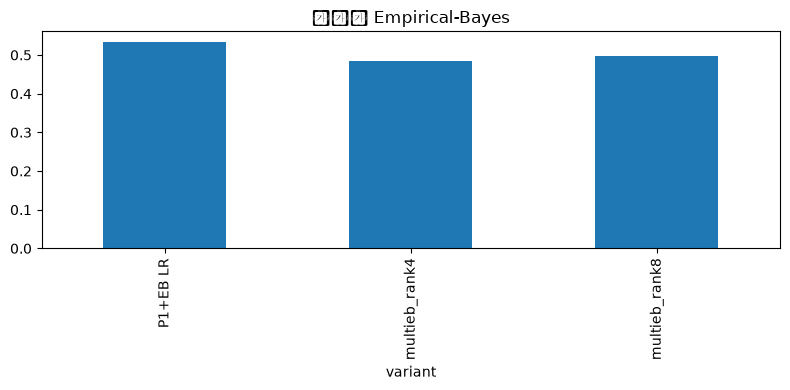

In [3]:
summary = pd.read_csv(RESULT / f"exp-multivariate-eb-01_seed{SEED}_summary.csv")
folds = pd.read_csv(RESULT / f"exp-multivariate-eb-01_seed{SEED}_fold_metrics.csv")
display(summary); display(folds)
assert summary.leakage_check.all()
assert summary.nan_as_mutation_count.eq(0).all()
summary.set_index("variant")["oof_macro_f1"].plot.bar(figsize=(8, 4), title="다변량 Empirical-Bayes")
plt.tight_layout(); plt.show()
